In [ ]:
%%capture
# ── Install Unsloth + inference stack ────────────────────────────────────────
!pip install unsloth

!pip install \
    "transformers>=4.51.3,<=5.5.0" \
    "trl>=0.18.2,<=0.24.0" \
    "peft>=0.18.0" \
    "accelerate>=0.34.1" \
    "bitsandbytes>=0.45.5"

!pip install Pillow wandb sentence_transformers datasets

In [ ]:
from google.colab import drive, userdata
import os, subprocess

# ┌─────────────────────────────────────────────────────────────────────────┐
# │  OPTION A — Google Colab                                                │
# │  Run this cell OR the local cell below. Not both.                       │
# └─────────────────────────────────────────────────────────────────────────┘

drive.mount('/content/drive')

DATA_DIR = "/content/drive/My Drive/ChoAI"

REPO_URL = "https://github.com/kasmello/ChoAI.git"
REPO_DIR = "/content/ChoAI"

if os.path.exists(REPO_DIR):
    result = subprocess.run(["git", "-C", REPO_DIR, "pull"], capture_output=True, text=True)
    print(result.stdout or "Already up to date.")
else:
    result = subprocess.run(["git", "clone", REPO_URL, REPO_DIR], capture_output=True, text=True)
    print(result.stdout)

if result.returncode != 0:
    print("Git error:", result.stderr)

os.chdir(REPO_DIR)

os.environ["WANDB_API_KEY"] = userdata.get("WANDB_API_KEY")

print(f"Working directory : {os.getcwd()}")
print(f"DATA_DIR          : {DATA_DIR}")

In [ ]:
import os
from dotenv import load_dotenv

# ┌─────────────────────────────────────────────────────────────────────────┐
# │  OPTION B — Local machine                                               │
# │  Run this cell OR the Colab cell above. Not both.                       │
# └─────────────────────────────────────────────────────────────────────────┘

# Add WANDB_API_KEY to your .env file (it's gitignored)
load_dotenv()

DATA_DIR = "."

print(f"Working directory : {os.getcwd()}")
print(f"DATA_DIR          : {os.path.abspath(DATA_DIR)}")
print(f"WANDB_API_KEY set : {'WANDB_API_KEY' in os.environ}")

In [ ]:
import requests
import json
import csv
import re
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
import matplotlib.image as mpimg
from io import StringIO, BytesIO
from tqdm import tqdm
import PIL
import time
import wandb
from sentence_transformers import SentenceTransformer, util
from transformers import TextStreamer
from unsloth import FastLanguageModel

# ── Secrets + paths ───────────────────────────────────────────────────────────
# WANDB_API_KEY, HF_TOKEN, and DATA_DIR are set by whichever config cell you
# ran above (Colab or local) — nothing Colab-specific in this cell.
os.environ["WANDB_PROJECT"] = "ChoAI"

# ── Load assets ───────────────────────────────────────────────────────────────
logo_img = mpimg.imread("Media/horizontal-logo.png")

with open(f"{DATA_DIR}/Training/final_file.json", "r") as json_file:
    data = json.load(json_file)

df = pd.read_csv(f"{DATA_DIR}/ProcessedData/Joined_DF.csv")
df["action_time"] = pd.to_datetime(df["action_time"], format="ISO8601")
df["Date"]        = pd.to_datetime(df["Date"])

# ── Fonts ─────────────────────────────────────────────────────────────────────
manjari_bold_path    = "font/Manjari-Bold.ttf"
manjari_regular_path = "font/Manjari-Regular.ttf"
manjari_thin_path    = "font/Manjari-thin.ttf"

manjari_bold    = fm.FontProperties(fname=manjari_bold_path)
manjari_regular = fm.FontProperties(fname=manjari_regular_path)
manjari_thin    = fm.FontProperties(fname=manjari_thin_path)

df

In [ ]:
# ── Build the column-list string used as model input ─────────────────────────
# The model was trained with column names as the 'Input' field in the Alpaca
# prompt, so we pass the same format at inference time.
sample_df      = pd.read_csv(f"{DATA_DIR}/ProcessedData/Joined_DF.csv")
training_input = str(list(sample_df.columns))


In [ ]:
# ── Saved adapters ────────────────────────────────────────────────────────────
# These are local paths to adapters saved by Training_Notebook.ipynb.
# In production, these would be loaded from a Modal Volume — see modal_app.py.
TRAINED_ADAPTERS = {
    "llama":   "Llama-3.2-3B-Instruct_0.0002_16_4bit",
    "mistral": "mistral-7b-instruct-v0.3_0.0002_16_4bit",
    "gemma":   "gemma-3-4b-it_0.0002_16_4bit",
    "qwen":    "Qwen2.5-Coder-7B-Instruct_0.0002_16_4bit",
}

test_prompts = [
    "give me a table of total sales grouped by staff - order it by sales",
    "how many photos were sold in august",
    "Can you produce a graph on who worked the most shifts?",
    "How many BTS albums sold in July?",
    "How many copies were sold over time?",
]

alpaca_prompt = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
{}

### Input:
{}

### Response:
{}"""

In [ ]:
all_outputs = {}
all_times   = {}

# ── Pick which adapter to evaluate ───────────────────────────────────────────
# Change EVAL_KEY to "gemma" or "qwen" to evaluate a different model.
EVAL_KEY     = "llama"
adapter_path = TRAINED_ADAPTERS[EVAL_KEY]   # local path to saved adapter

dtype          = None
max_seq_length = 2048
load_in_4bit   = True

# ── Load base model + LoRA adapter ───────────────────────────────────────────
# Loads from a local directory saved by Training_Notebook.ipynb.
# In production this path would point to a Modal Volume mount instead.
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = adapter_path,
    max_seq_length = max_seq_length,
    dtype          = dtype,
    load_in_4bit   = load_in_4bit,
)
FastLanguageModel.for_inference(model)

outputs = []
times   = []

for prompt in tqdm(test_prompts):
    inputs = tokenizer(
        [alpaca_prompt.format(prompt, training_input, "")],
        return_tensors="pt"
    ).to("cuda")

    start_time = time.time()
    output     = model.generate(**inputs, max_new_tokens=2048)
    end_time   = time.time()

    output_text = tokenizer.decode(output[0], skip_special_tokens=True)
    text_output = re.search(r"### Response:\s*(.*)", output_text, re.DOTALL).group(1).strip()
    instruction = re.search(r"### Instruction:\s*(.*?)\s*### Input:", output_text, re.DOTALL).group(1).strip()

    outputs.append([text_output, instruction, output_text])
    times.append(end_time - start_time)

all_outputs[adapter_path] = outputs
all_times[adapter_path]   = times

with open("all_outputs.json", "w") as fp:
    json.dump(all_outputs, fp)
with open("all_times.json", "w") as fp:
    json.dump(all_times, fp)

print(f"Inference complete for {adapter_path}")

mistral-7b-instruct-v0.3_0.0002_16_4bit_quantized


Success
No Title found!
Success
No Title found!
Success
No Title found!
Failed exception: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().
No Title found!
Success
No Title found!


Testing Evaluation Loss,0.03235
eval/loss,0.03235
eval/runtime,88.2487
eval/samples_per_second,2.028
eval/steps_per_second,0.261
lora_alpha,16
lr,0.0002
model_name,mistral-7b-instruct-...
total_flos,39987297833877500
train/epoch,1.11732
train/global_step,200


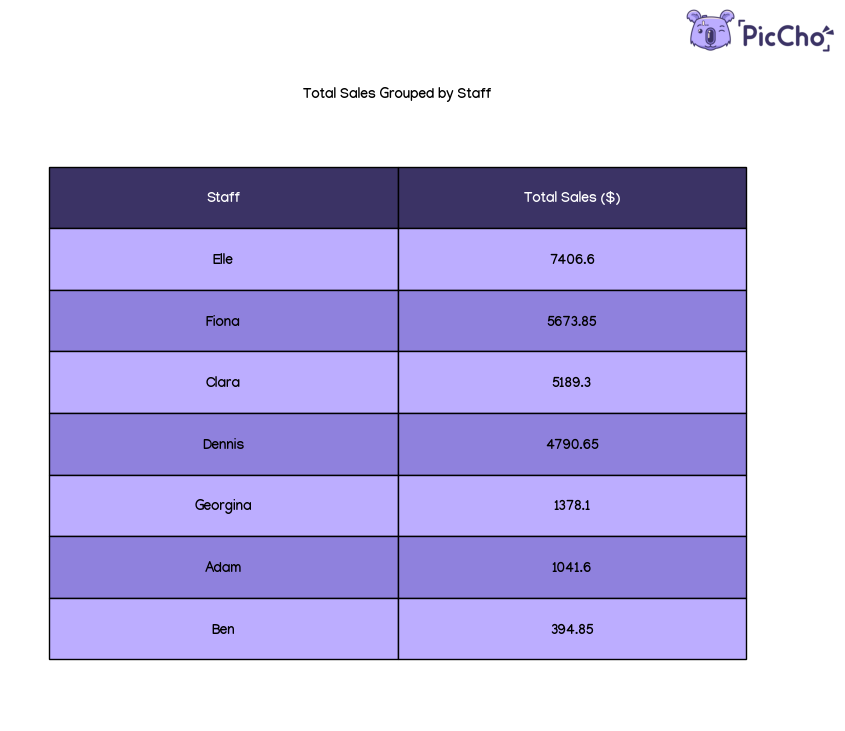

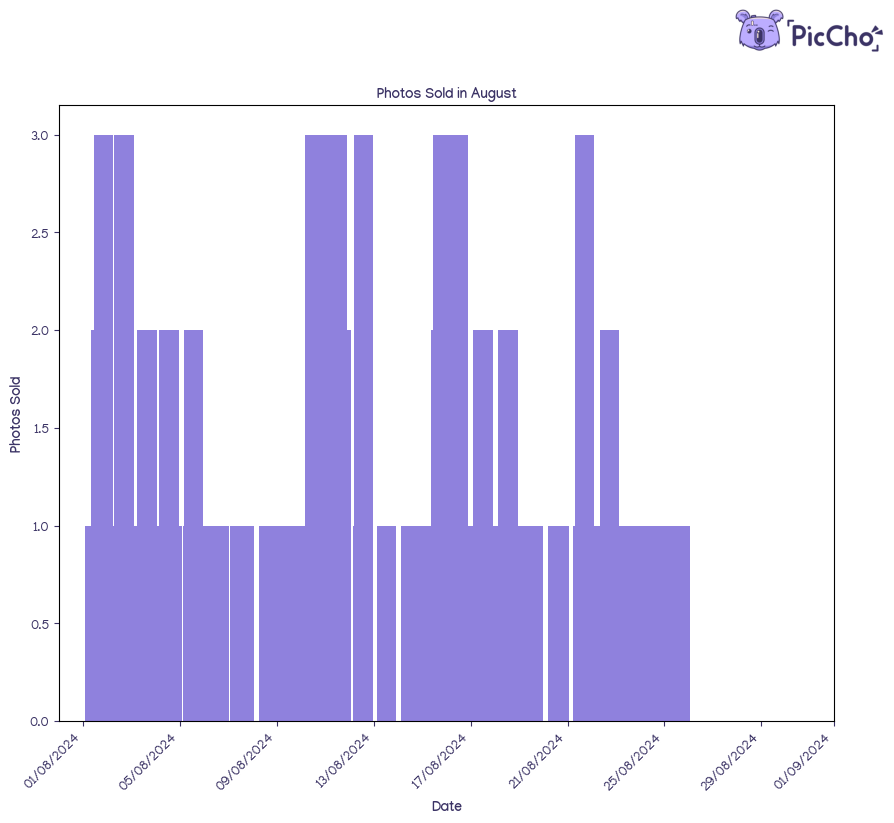

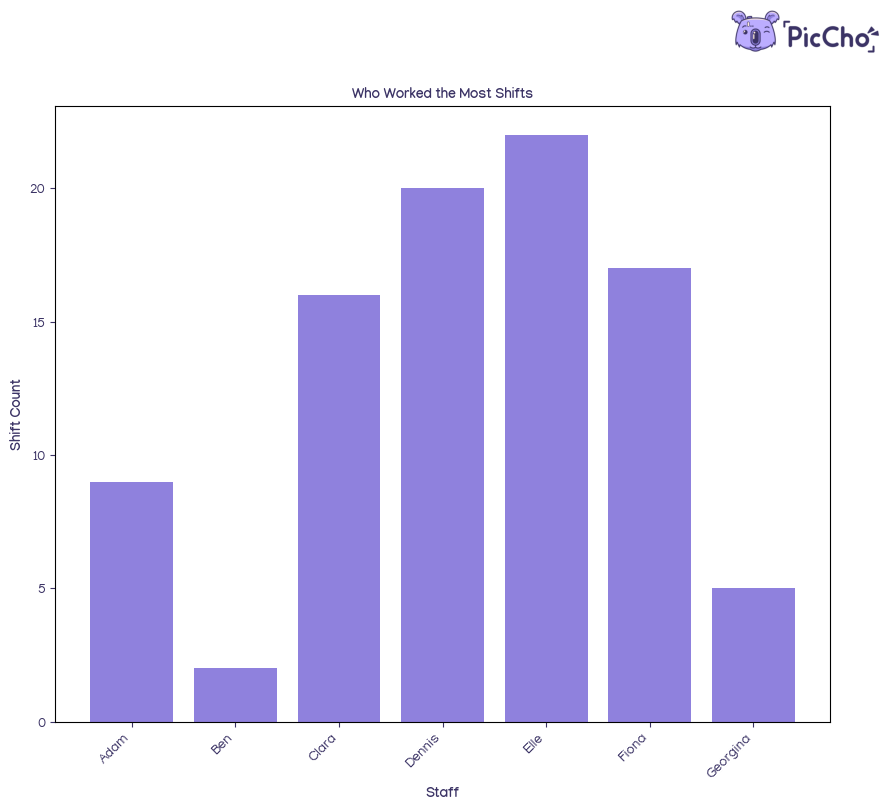

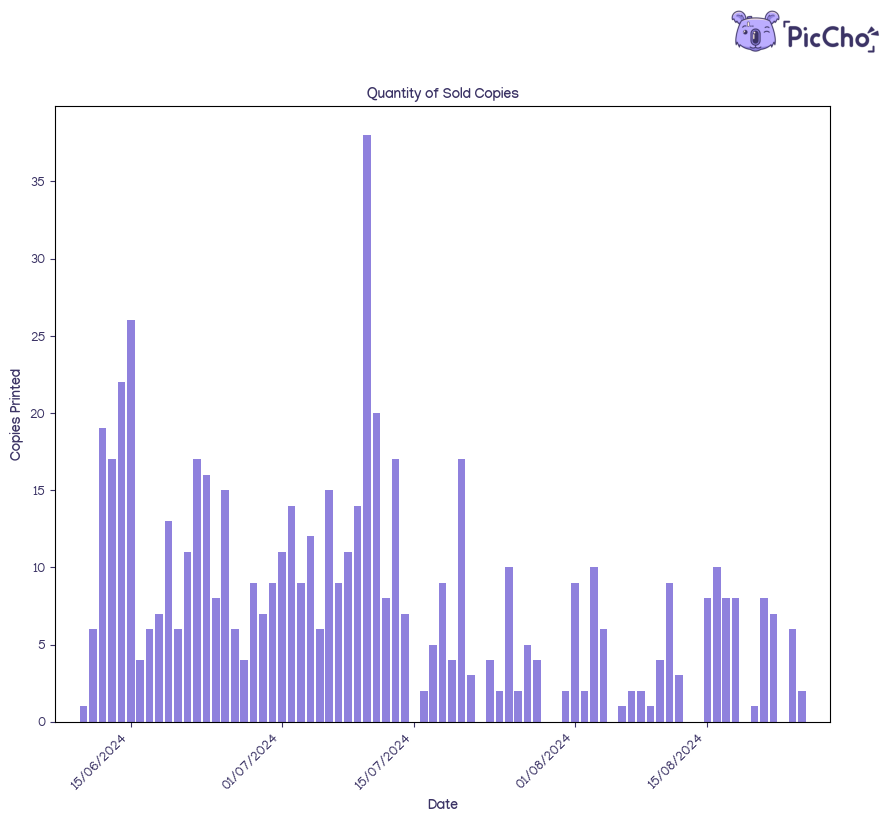

In [ ]:
with open('all_outputs.json', 'r') as fp:
    all_outputs = json.load(fp)

with open('all_times.json', 'r') as fp:
    all_times = json.load(fp)

title_check = SentenceTransformer('all-MiniLM-L6-v2')
# check multiple models
api = wandb.Api()

def scoring_syntax(output):
  try:
    exec(output)
    print("Success")
    return 1
  except Exception as error:
    print(f"Failed exception: {error}")
    return 0


def scoring_title(query,output):
  title = re.search(r"\.(?:title|set_title)\(['\"](.*?)['\"]\)", output)
  if not title:
    print('No Title found!')
    return 0
  query_embedding = title_check.encode(query, convert_to_tensor=True)
  title_embedding = title_check.encode(title, convert_to_tensor=True)

  # Compute cosine similarity
  similarity = util.cos_sim(query_embedding, title_embedding)
  return similarity.item()


def scoring_elements(output):
  score = 0

  #checking if graph uses Manjari
  if 'manjari' in output:
    score += 0.5

  #checking if logo is on the visualisation
  if 'logo_img' in output:
    score += 0.5

  return score

def return_run(name):
  runs = api.runs("kasmello/ChoAI")

  for run in runs:
    if run.name == name:
      print(name)
      return run.id

  print("Run not found")
  return None



model_name = 'mistral-7b-instruct-v0.3_0.0002_16_4bit_quantized'
run_id = return_run(model_name.replace('unsloth/',''))
run = wandb.init(project='ChoAI', id=run_id, resume="allow")
output = all_outputs[model_name]
times = all_times[model_name]
columns=['Model','Instruction','Output','Syntax','Title','Elements','Inference Time']
data = [[
    model_name.replace('unsloth/',''),
    output[i][1],
    output[i][0],
    scoring_syntax(output[i][0]),
    scoring_title(output[i][1],output[i][0]),
    scoring_elements(output[i][0]),
    times[i]
] for i in range(len(output))]
wandb_table = wandb.Table(columns=columns, data=data)
wandb.log({"Inference Scores":wandb_table})
run.finish()






